# GSA Timetabling

Revenue-maximizing railway timetabling solved with the custom Gravitational
Search Algorithm (GSA). Like the mealpy backend, GSA optimizes the real-valued
departure times while the discrete part (scheduled services) is obtained with
the conflict-avoiding heuristic.


## 0. Load Libraries


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from pathlib import Path

from robin.supply.generator.entities import SupplyGenerator
from robin.supply.entities import Supply

from craft import RevenueSimulator, Solution
from craft.gsa import GSA, Boundaries
from craft.mealpy import MealpyTimetabling

## 1. Generate Supply


In [2]:
supply_config_path = Path('../configs/supply_generator/supply_data.yaml')
generator_config_path = Path('../configs/supply_generator/config.yaml')
generator_save_path = Path('../data/results/supply_gsa.yaml')

Path('../data/results').mkdir(parents=True, exist_ok=True)

generator = SupplyGenerator.from_yaml(
    path_config_supply=supply_config_path,
    path_config_generator=generator_config_path,
)

generator.generate(
    n_services=25,
    output_path=generator_save_path,
    seed=42,
    progress_bar=True,
    without_conflicts=False,
)

print(f'Generated {len(generator.services)} services')

Generating services all: 100%|██████████| 25/25 [00:00<00:00, 409.77service/s]

Generated 25 services


## 2. Load Supply and Generate Revenue Behavior


In [3]:
supply = Supply.from_yaml(path=str(generator_save_path))
print(f'Loaded {len(supply.services)} services')

revenue_simulator = RevenueSimulator(supply=supply)
revenue_behavior = revenue_simulator.simulate_revenue(alpha=2/3)

print(f'Revenue behavior computed for {len(revenue_behavior)} services')

Loaded 25 services
Revenue behavior computed for 25 services


## 3. Initialize Timetabling Problem


In [4]:
timetabling = MealpyTimetabling(
    requested_services=supply.services,
    revenue_behavior=revenue_behavior,
    safe_headway=10,
    max_stop_time=10,
)

print(f'Problem initialized with {timetabling.n_services} services')
print(f'Real variables: {len(timetabling.boundaries.real)}')

Problem initialized with 25 services
Real variables: 81


## 4. Define Objective Function for GSA

GSA's objective function must return a `(fitness, accuracy)` tuple. We wrap
the timetabling problem so that GSA updates the schedule from the real-valued
departure times, computes the discrete schedule with the conflict-avoiding
heuristic, and returns the revenue plus the scheduled-services ratio as
accuracy.


In [5]:
def gsa_objective(solution):
    sol_arr = np.array(solution.real, dtype=np.int32)
    timetabling.schedule_manager.update_from_solution(sol_arr)
    timetabling.revenue_calculator.updated_schedule = timetabling.schedule_manager.updated_schedule
    timetabling.revenue_calculator.recompute_all_revenues()

    schedule = timetabling.get_heuristic_schedule()
    revenue = timetabling.get_revenue(Solution(real=solution.real, discrete=schedule))
    accuracy = float(np.sum(schedule)) / len(schedule)
    return revenue, accuracy

## 5. Run GSA Optimization


In [6]:
n_real = len(timetabling.boundaries.real)
boundaries = Boundaries(real=timetabling.boundaries.real, discrete=[])

gsa = GSA(
    objective_function=gsa_objective,
    r_dim=n_real,
    d_dim=0,
    boundaries=boundaries,
)

history = gsa.optimize(
    population_size=20,
    iters=50,
    seed=42,
    verbose=False,
)

print(f'Best fitness: {gsa.best_fitness}')

Best fitness: 549.5227682806942


## 6. Results


In [7]:
best_solution = gsa.best_solution
print(f'Best fitness: {gsa.best_fitness}')
print(f'Best solution real variables: {len(best_solution.real)}')

history.tail(10)

Best fitness: 549.5227682806942
Best solution real variables: 81


,Iteration,Fitness,Accuracy,ExecutionTime,Discrete,Real
40,41,549.522768,0.92,0.440010,[],"[416.7549212589882, 480.98434748223394, 706.64..."
41,42,549.522768,0.92,0.450671,[],"[416.7549212589882, 480.98434748223394, 706.64..."
42,43,549.522768,0.92,0.461277,[],"[416.7549212589882, 480.98434748223394, 706.64..."
43,44,549.522768,0.92,0.472318,[],"[416.7549212589882, 480.98434748223394, 706.64..."
44,45,549.522768,0.92,0.482221,[],"[416.7549212589882, 480.98434748223394, 706.64..."
45,46,549.522768,0.92,0.491971,[],"[416.7549212589882, 480.98434748223394, 706.64..."
46,47,549.522768,0.92,0.501841,[],"[416.7549212589882, 480.98434748223394, 706.64..."
47,48,549.522768,0.92,0.511664,[],"[416.7549212589882, 480.98434748223394, 706.64..."
48,49,549.522768,0.92,0.521256,[],"[416.7549212589882, 480.98434748223394, 706.64..."
49,50,549.522768,0.92,0.530720,[],"[416.7549212589882, 480.98434748223394, 706.64..."


## 7. Update Supply with Solution


In [8]:
schedule = timetabling.get_heuristic_schedule()
solution = Solution(real=best_solution.real, discrete=schedule)
updated_services = timetabling.update_supply(str(generator_save_path), solution)

print(f'Updated supply contains {len(updated_services)} services')
print(f'Scheduled services: {sum(schedule)}/{len(schedule)}')

Updated supply contains 23 services
Scheduled services: 23/25


## 8. Convergence


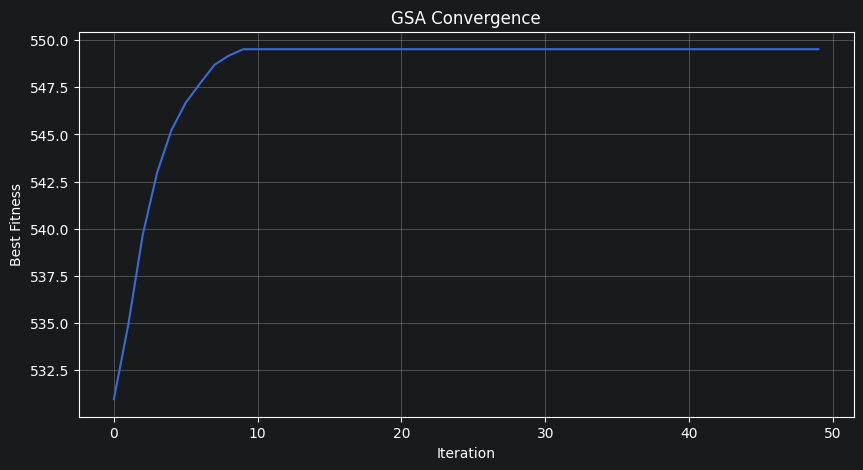

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(gsa.convergence)
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.title('GSA Convergence')
plt.grid(True)
plt.show()